In [1]:
"""
Примеры кода к Лекции 5.4: Persistence и Time Travel

Этот модуль демонстрирует:
1. MemorySaver — checkpointer для разработки
2. thread_id — изоляция разговоров
3. PostgresSaver / RedisSaver — checkpointer'ы для продакшна
4. Просмотр и обновление состояния, recovery после сбоев
5. Store — долгосрочная память между потоками
6. Time Travel — история, replay, fork
7. Debugging — LangSmith, визуализация графа
8. Управление длиной истории (trim_messages, RemoveMessage)
"""

"\nПримеры кода к Лекции 5.4: Persistence и Time Travel\n\nЭтот модуль демонстрирует:\n1. MemorySaver — checkpointer для разработки\n2. thread_id — изоляция разговоров\n3. PostgresSaver / RedisSaver — checkpointer'ы для продакшна\n4. Просмотр и обновление состояния, recovery после сбоев\n5. Store — долгосрочная память между потоками\n6. Time Travel — история, replay, fork\n7. Debugging — LangSmith, визуализация графа\n8. Управление длиной истории (trim_messages, RemoveMessage)\n"

In [2]:
import time

from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    RemoveMessage,
    SystemMessage,
    trim_messages,
)
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from llm_config import check_api_key, get_llm

In [3]:
if not check_api_key():
    raise ValueError("API key is not set")
else:
    print("API key is set")

API key is set


## Checkpointers — хранители состояния

In [4]:
llm = get_llm()

# Узел чат-бота
def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент. Отвечай кратко.")]
        + state["messages"]
    )
    return {"messages": [response]}

# Строим граф
graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

# Компилируем С checkpointer'ом — единственное изменение
memory = MemorySaver()
app = graph.compile(checkpointer=memory)

print("\n  Граф скомпилирован с MemorySaver")
print("  Теперь каждый вызов сохраняет состояние автоматически")



  Граф скомпилирован с MemorySaver
  Теперь каждый вызов сохраняет состояние автоматически


## thread_id — изоляция разговоров

In [5]:
llm = get_llm()

def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент. Отвечай кратко.")]
        + state["messages"]
    )
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)

# Первый разговор — Алиса
config1 = {"configurable": {"thread_id": "user-alice-001"}}

result = app.invoke(
    {"messages": [HumanMessage(content="Меня зовут Алиса")]},
    config=config1,
)
print(f"\n  [Алиса] Ответ: {result['messages'][-1].content[:80]}")

# Продолжение — граф ПОМНИТ
result = app.invoke(
    {"messages": [HumanMessage(content="Как меня зовут?")]},
    config=config1,
)
print(f"  [Алиса] Ответ: {result['messages'][-1].content[:80]}")

# Другой разговор — изолирован
config2 = {"configurable": {"thread_id": "user-bob-001"}}
result = app.invoke(
    {"messages": [HumanMessage(content="Как меня зовут?")]},
    config=config2,
)
print(f"  [Боб]   Ответ: {result['messages'][-1].content[:80]}")


  [Алиса] Ответ: Приятно познакомиться, Алиса!


  [Алиса] Ответ: Тебя зовут Алиса.


  [Боб]   Ответ: Я не знаю вашего имени, если вы его не называли.


## Управление состоянием и recovery

In [6]:
llm = get_llm()

def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент.")] + state["messages"]
    )
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "user-alice-001"}}

app.invoke({"messages": [HumanMessage(content="Привет!")]}, config=config)

# Получаем текущее состояние потока
state = app.get_state(config)
print(f"\n  Состояние: {len(state.values.get('messages', []))} сообщений")
print(f"  Следующие узлы: {state.next}")  # Пусто = граф завершён
print(f"  Время checkpoint'а: {state.created_at}")


  Состояние: 2 сообщений
  Следующие узлы: ()
  Время checkpoint'а: 2026-04-07T16:20:24.808123+00:00


## Обновление состояния извне

In [7]:
llm = get_llm()

def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент.")] + state["messages"]
    )
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "user-alice-001"}}

app.invoke({"messages": [HumanMessage(content="Привет!")]}, config=config)

# Добавляем сообщение извне — reducer add_messages добавит его к истории
app.update_state(
    config,
    {
        "messages": [
            AIMessage(content="[Системное уведомление: пользователь верифицирован]")
        ]
    },
)

state = app.get_state(config)
print(f"\n  Сообщений после update_state: {len(state.values.get('messages', []))}")


  Сообщений после update_state: 3


## Recovery после сбоев

In [8]:
llm = get_llm()

def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент.")] + state["messages"]
    )
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "long-task-001"}}
initial_state = {"messages": [HumanMessage(content="Расскажи о Python")]}

try:
    result = app.invoke(initial_state, config=config)
    print(f"\n  Успешно: {result['messages'][-1].content[:60]}...")
except Exception as e:
    print(f"\n  Граф упал: {e}")

    # Проверяем, где остановились
    state = app.get_state(config)
    print(f"  Следующие узлы: {state.next}")

    # Продолжаем с места остановки
    result = app.invoke(None, config=config)
    print(f"  Восстановлено: {result['messages'][-1].content[:60]}...")


  Успешно: Python — это популярный высокоуровневый язык программировани...


## Retry с exponential backoff

In [9]:
llm = get_llm()

def chatbot(state: MessagesState) -> dict:
    response = llm.invoke(
        [SystemMessage(content="Ты — дружелюбный ассистент.")] + state["messages"]
    )
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "resilient-001"}}
initial_state = {"messages": [HumanMessage(content="Расскажи о Python")]}

for attempt in range(3):
    try:
        state = app.get_state(config)
        if state.values and state.next:
            result = app.invoke(None, config=config)  # Продолжить
        else:
            result = app.invoke(initial_state, config=config)  # Начать
        print(f"\n  Попытка {attempt + 1}: успех")
        break
    except Exception as e:
        print(f"\n  Попытка {attempt + 1}: {e}")
        time.sleep(2**attempt)


  Попытка 1: успех


## Store — долгосрочная память между потоками

In [10]:
llm = get_llm()

store = InMemoryStore()

# Узел с доступом к Store через keyword-аргумент
def chatbot_with_memory(state: MessagesState, *, store: BaseStore) -> dict:
    user_id = "alice"  # В реальности — из конфигурации

    # Читаем долгосрочные воспоминания
    memories = store.search(("user_memories", user_id))
    memory_text = (
        "\n".join(m.value["text"] for m in memories) if memories else "Нет"
    )

    response = llm.invoke(
        [
            SystemMessage(content=f"Что ты помнишь о пользователе:\n{memory_text}"),
            *state["messages"],
        ]
    )

    # Сохраняем новое воспоминание
    store.put(
        ("user_memories", user_id),
        key=f"mem-{len(memories)}",
        value={"text": f"Пользователь сказал: {state['messages'][-1].content}"},
    )

    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot_with_memory)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

# Компилируем с checkpointer И store
app = graph.compile(checkpointer=MemorySaver(), store=store)

# Первый разговор
config1 = {"configurable": {"thread_id": "thread-1"}}
app.invoke(
    {"messages": [HumanMessage(content="Я люблю Python")]},
    config=config1,
)

# Второй разговор — Store помнит, что пользователь сказал раньше
config2 = {"configurable": {"thread_id": "thread-2"}}
result = app.invoke(
    {"messages": [HumanMessage(content="Что ты знаешь обо мне?")]},
    config=config2,
)

print(f"\n  Ответ во втором потоке: {result['messages'][-1].content[:100]}...")


  Ответ во втором потоке: Я знаю только то, что ты сам уже сказал: ты любишь Python.  

Если хочешь, я могу запомнить о тебе е...


## Time travel — история и воспроизведение

In [11]:
def _build_pipeline_graph():
    """
    Вспомогательная функция: строит трёхшаговый граф (research → write → edit).
    Используется в примерах Time Travel, Replay и Fork.
    """
    llm = get_llm()

    def researcher(state: MessagesState) -> dict:
        response = llm.invoke(
            [SystemMessage(content="Найди ключевые факты по теме."), *state["messages"]]
        )
        return {"messages": [response]}

    def writer(state: MessagesState) -> dict:
        response = llm.invoke(
            [SystemMessage(content="Напиши краткую статью."), *state["messages"]]
        )
        return {"messages": [response]}

    def editor(state: MessagesState) -> dict:
        response = llm.invoke(
            [
                SystemMessage(content="Отредактируй: исправь ошибки, улучши стиль."),
                *state["messages"],
            ]
        )
        return {"messages": [response]}

    graph = StateGraph(MessagesState)
    graph.add_node("research", researcher)
    graph.add_node("write", writer)
    graph.add_node("edit", editor)
    graph.add_edge(START, "research")
    graph.add_edge("research", "write")
    graph.add_edge("write", "edit")
    graph.add_edge("edit", END)

    return graph


graph = _build_pipeline_graph()
app = graph.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "article-001"}}
result = app.invoke(
    {"messages": [HumanMessage(content="Статья про квантовые компьютеры")]},
    config=config,
)

# Просматриваем историю checkpoint'ов
print("\n  История checkpoint'ов:")
for state in app.get_state_history(config):
    checkpoint_id = state.config["configurable"]["checkpoint_id"]
    next_nodes = state.next
    msg_count = len(state.values.get("messages", []))
    print(f"    {checkpoint_id}: следующий={next_nodes}, сообщений={msg_count}")



  История checkpoint'ов:
    1f1329db-a47d-63b2-8003-ac0ad1fa9cd1: следующий=(), сообщений=4
    1f1329db-832b-6272-8002-f84585e6d2e6: следующий=('edit',), сообщений=3
    1f1329db-5b69-6770-8001-d6a1a99095fb: следующий=('write',), сообщений=2
    1f1329db-3a3f-6252-8000-ecb88f6fdc0e: следующий=('research',), сообщений=1
    1f1329db-3a3d-6d44-bfff-53a3894951ce: следующий=('__start__',), сообщений=0


## Replay — перезапуск с произвольной точки

In [12]:
graph = _build_pipeline_graph()
app = graph.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "article-002"}}
app.invoke(
    {"messages": [HumanMessage(content="Статья про квантовые компьютеры")]},
    config=config,
)

# Находим checkpoint перед write
target_config = None
for state in app.get_state_history(config):
    if state.next == ("write",):
        target_config = state.config
        break

if target_config:
    # Перезапускаем — research НЕ повторяется, экономим API-вызов
    result = app.invoke(None, config=target_config)
    print(f"\n  Replay выполнен, сообщений: {len(result['messages'])}")


  Replay выполнен, сообщений: 4


## Replay с модификацией состояния

In [13]:
graph = _build_pipeline_graph()
app = graph.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "article-003"}}
app.invoke(
    {"messages": [HumanMessage(content="Статья про квантовые компьютеры")]},
    config=config,
)

# Находим checkpoint перед write
target_config = None
for state in app.get_state_history(config):
    if state.next == ("write",):
        target_config = state.config
        break

if target_config:
    # Добавляем инструкцию от имени research
    app.update_state(
        target_config,
        {
            "messages": [
                HumanMessage(content="Пиши в научно-популярном стиле, без жаргона")
            ]
        },
        as_node="research",  # Как будто это сообщение от research
    )

    # Следующим будет write — он увидит дополнительную инструкцию
    result = app.invoke(None, config=target_config)
    print(
        f"\n  Replay с модификацией выполнен, сообщений: {len(result['messages'])}"
    )


  Replay с модификацией выполнен, сообщений: 4


## Fork — ветвление выполнения

In [14]:
graph = _build_pipeline_graph()
app = graph.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "article-004"}}
app.invoke(
    {"messages": [HumanMessage(content="Статья про квантовые компьютеры")]},
    config=config,
)

# Находим нужную точку для ветвления
checkpoints = list(app.get_state_history(config))
if len(checkpoints) >= 3:
    fork_point = checkpoints[2].config  # Третий с конца

    # Обновляем — создаётся ветка, оригинал не затрагивается
    app.update_state(
        fork_point,
        {"messages": [HumanMessage(content="Давай попробуем другой подход...")]},
        as_node="research",
    )

    print("\n  Fork создан. Структура истории:")
    print("    ck-001 (start)")
    print("      +-- ck-002 (after research)")
    print("            +-- ck-003 (after write)")
    print("                  +-- ck-004 (after edit)  <-- оригинал")
    print("                  +-- ck-005 (forked)      <-- альтернатива")


  Fork создан. Структура истории:
    ck-001 (start)
      +-- ck-002 (after research)
            +-- ck-003 (after write)
                  +-- ck-004 (after edit)  <-- оригинал
                  +-- ck-005 (forked)      <-- альтернатива


## Debugging — практические техники

In [15]:
# Включаем трассировку через переменные окружения
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "my-agent-debug"

# Дальше — как обычно. LangSmith записывает всё автоматически.
print("""
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "my-agent-debug"

# Дальше используем граф как обычно.
# В LangSmith будет видно: дерево вызовов, промпты, ответы,
# время, токены, стоимость каждого шага.
""")


import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "my-agent-debug"

# Дальше используем граф как обычно.
# В LangSmith будет видно: дерево вызовов, промпты, ответы,
# время, токены, стоимость каждого шага.



## Визуализация графа


  ASCII-визуализация:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+----------+   
| research |   
+----------+   
      *        
      *        
      *        
  +-------+    
  | write |    
  +-------+    
      *        
      *        
      *        
  +------+     
  | edit |     
  +------+     
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   

  Mermaid-диаграмма:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research(research)
	write(write)
	edit(edit)
	__end__([<p>__end__</p>]):::last
	__start__ --> research;
	research --> write;
	write --> edit;
	edit --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



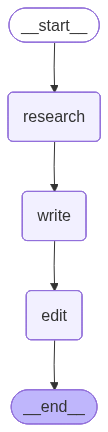

In [16]:
graph = _build_pipeline_graph()
app = graph.compile(checkpointer=MemorySaver())

# ASCII-визуализация (работает в терминале)
print("\n  ASCII-визуализация:")
app.get_graph().print_ascii()

# Mermaid-диаграмма (для Jupyter, документации)
print("\n  Mermaid-диаграмма:")
print(app.get_graph().draw_mermaid())

# PNG (для Jupyter)
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# С развёрнутыми подграфами
# print(app.get_graph(xray=True).draw_mermaid())

## Управление длиной истории

In [17]:
llm = get_llm()

def chatbot_with_trimming(state: MessagesState) -> dict:
    # Обрезаем для LLM, но в состоянии хранится полная история
    trimmed = trim_messages(
        state["messages"],
        max_tokens=4000,
        token_counter=llm,
        strategy="last",
        start_on="human",
        include_system=True,
    )
    response = llm.invoke(trimmed)
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("chatbot", chatbot_with_trimming)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile(checkpointer=MemorySaver())

print("\n  Граф с trim_messages скомпилирован")
print("  Модель видит последние 4000 токенов, состояние хранит всё")


  Граф с trim_messages скомпилирован
  Модель видит последние 4000 токенов, состояние хранит всё


## RemoveMessage — очистка состояния

In [18]:
def cleanup_old_messages(state: MessagesState) -> dict:
    """Удаляет старые сообщения, если их больше 50."""
    if len(state["messages"]) > 50:
        to_remove = [RemoveMessage(id=m.id) for m in state["messages"][:-30]]
        return {"messages": to_remove}
    return {}

print("\n  Функция cleanup_old_messages:")
print("    Если сообщений > 50, удаляет все кроме последних 30")
print("    RemoveMessage удаляет по id через reducer")


  Функция cleanup_old_messages:
    Если сообщений > 50, удаляет все кроме последних 30
    RemoveMessage удаляет по id через reducer
